# Real-world Data Project — Finance
### Task 4 — End-to-end analysis and prediction on Apple (AAPL) stock price data

**Domain chosen:** Finance — historical daily stock price data.

**Dataset:** Daily OHLC (open/high/low/close) prices, volume, and adjusted close for **AAPL (Apple Inc.)**
covering ~506 trading days (Feb 2015 – Feb 2017). This is a realistic finance dataset: it has time-series
structure, noisy/volatile behavior, and a genuine, well-known applied question (can recent price action predict
tomorrow's direction?).

**Plan (end-to-end):**
1. Load & clean the data
2. Exploratory analysis — trend, moving averages, returns, volatility
3. Feature engineering for prediction
4. Predictive model — will tomorrow's close be **up or down**?
5. Findings & conclusions


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 4.5)


## 1. Load & clean the data

In [2]:
df = pd.read_csv("apple_stock.csv", parse_dates=["Date"])
df = df.sort_values("Date").reset_index(drop=True)
df = df.rename(columns={
    "AAPL.Open": "open", "AAPL.High": "high", "AAPL.Low": "low",
    "AAPL.Close": "close", "AAPL.Volume": "volume", "AAPL.Adjusted": "adj_close",
})
print(df.shape)
df.head()


(506, 11)


,Date,open,high,low,close,volume,adj_close,dn,mavg,up,direction
0,2015-02-17,127.489998,128.880005,126.919998,127.830002,63152400,122.905254,106.741052,117.927667,129.114281,Increasing
1,2015-02-18,127.629997,128.779999,127.449997,128.720001,44891700,123.760965,107.842423,118.940333,130.038244,Increasing
2,2015-02-19,128.479996,129.029999,128.330002,128.449997,37362400,123.501363,108.894245,119.889167,130.884089,Decreasing
3,2015-02-20,128.619995,129.500000,128.050003,129.500000,48948400,124.510914,109.785449,120.763500,131.741551,Increasing
4,2015-02-23,130.020004,133.000000,129.660004,133.000000,70974100,127.876074,110.372516,121.720167,133.067817,Increasing


In [3]:
df.info()
df.isna().sum()


<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       506 non-null    datetime64[us]
 1   open       506 non-null    float64       
 2   high       506 non-null    float64       
 3   low        506 non-null    float64       
 4   close      506 non-null    float64       
 5   volume     506 non-null    int64         
 6   adj_close  506 non-null    float64       
 7   dn         506 non-null    float64       
 8   mavg       506 non-null    float64       
 9   up         506 non-null    float64       
 10  direction  506 non-null    str           
dtypes: datetime64[us](1), float64(8), int64(1), str(1)
memory usage: 43.6 KB


Date         0
open         0
high         0
low          0
close        0
volume       0
adj_close    0
dn           0
mavg         0
up           0
direction    0
dtype: int64

No missing values and dates are already daily trading-day granularity, so no imputation is required.

## 2. Exploratory analysis

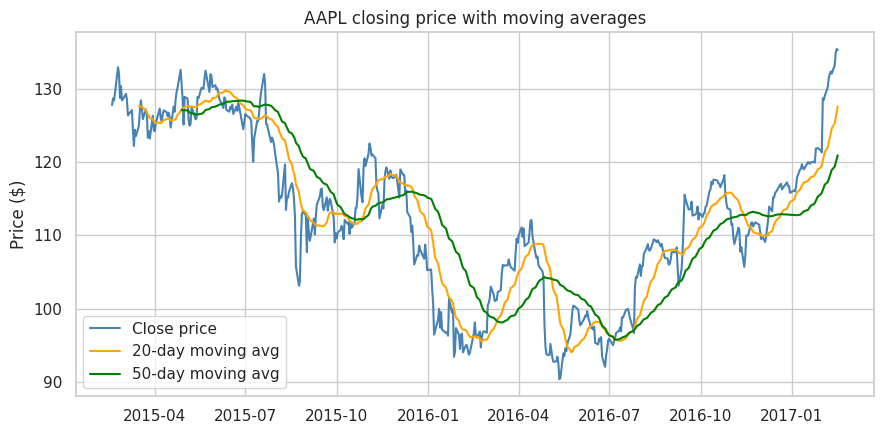

In [4]:
fig, ax = plt.subplots()
ax.plot(df["Date"], df["close"], label="Close price", color="steelblue")
ax.plot(df["Date"], df["close"].rolling(20).mean(), label="20-day moving avg", color="orange")
ax.plot(df["Date"], df["close"].rolling(50).mean(), label="50-day moving avg", color="green")
ax.set_title("AAPL closing price with moving averages")
ax.set_ylabel("Price ($)")
ax.legend()
plt.tight_layout()
plt.show()


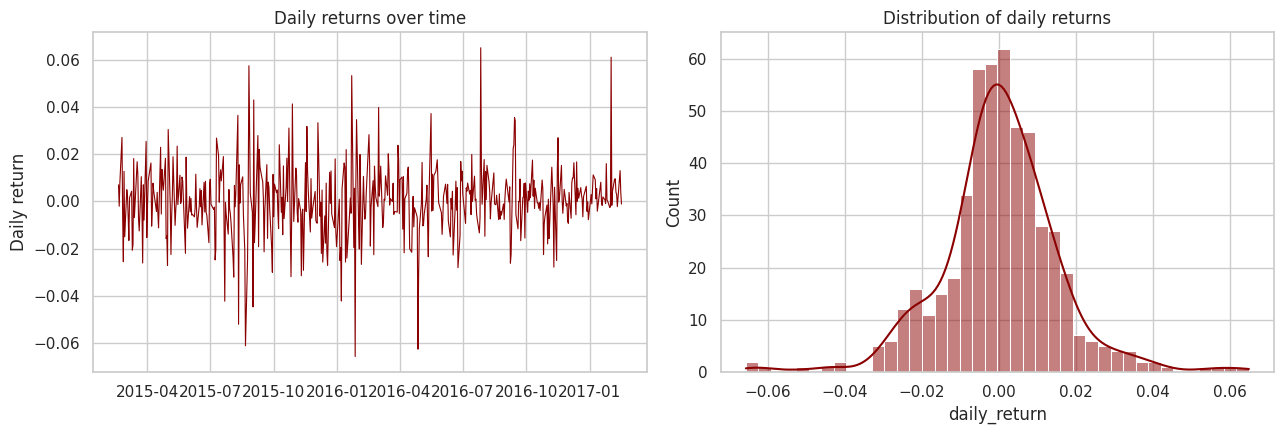

Mean daily return: 0.00023
Daily volatility (std): 0.01529
Annualized volatility (approx): 0.243


In [5]:
df["daily_return"] = df["close"].pct_change()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(df["Date"], df["daily_return"], color="darkred", linewidth=0.8)
axes[0].set_title("Daily returns over time")
axes[0].set_ylabel("Daily return")

sns.histplot(df["daily_return"].dropna(), bins=40, kde=True, ax=axes[1], color="darkred")
axes[1].set_title("Distribution of daily returns")
plt.tight_layout()
plt.show()

print("Mean daily return:", round(df['daily_return'].mean(), 5))
print("Daily volatility (std):", round(df['daily_return'].std(), 5))
print("Annualized volatility (approx):", round(df['daily_return'].std() * np.sqrt(252), 3))


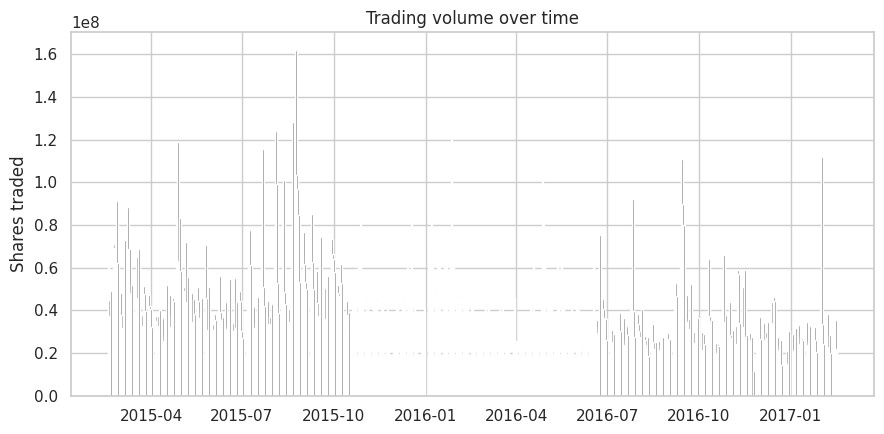

In [6]:
fig, ax = plt.subplots()
ax.bar(df["Date"], df["volume"], width=1.5, color="gray")
ax.set_title("Trading volume over time")
ax.set_ylabel("Shares traded")
plt.tight_layout()
plt.show()


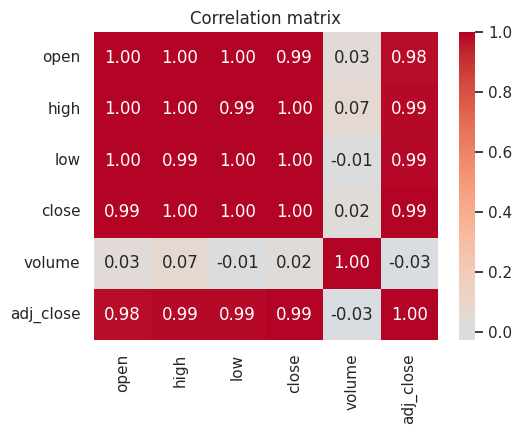

In [7]:
numeric_cols = ["open", "high", "low", "close", "volume", "adj_close"]
corr = df[numeric_cols].corr()

plt.figure(figsize=(5.5, 4.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation matrix")
plt.tight_layout()
plt.show()


**Observations so far:**
- Price trended upward over the two years with the 50-day average smoothing out short-term noise — classic
  visual confirmation of an uptrend.
- Daily returns cluster tightly around 0 with a few larger spikes (volatility "clusters" typical of real
  markets) rather than a clean bell curve.
- Open/High/Low/Close/Adjusted-close are, unsurprisingly, almost perfectly correlated with each other; volume
  is only weakly correlated with price levels.


## 3. Feature engineering for prediction
To predict next-day direction, features are built only from information available **up to and including**
today's close — no lookahead into the future.


In [8]:
feat = df.copy()
feat["return_1d"] = feat["close"].pct_change(1)
feat["return_5d"] = feat["close"].pct_change(5)
feat["ma_5"] = feat["close"].rolling(5).mean()
feat["ma_20"] = feat["close"].rolling(20).mean()
feat["ma_ratio"] = feat["ma_5"] / feat["ma_20"]
feat["volatility_5d"] = feat["daily_return"].rolling(5).std()
feat["volume_change"] = feat["volume"].pct_change()

# Target: will TOMORROW's close be higher than today's close?
feat["target_up"] = (feat["close"].shift(-1) > feat["close"]).astype(int)

feature_cols = ["return_1d", "return_5d", "ma_ratio", "volatility_5d", "volume_change"]
feat = feat.dropna(subset=feature_cols + ["target_up"]).reset_index(drop=True)
feat[["Date"] + feature_cols + ["target_up"]].head()


,Date,return_1d,return_5d,ma_ratio,volatility_5d,volume_change,target_up
0,2015-03-16,0.011004,-0.017225,0.970535,0.017320,-0.307811,1
1,2015-03-17,0.016727,0.020320,0.974799,0.015988,0.422274,1
2,2015-03-18,0.011256,0.050965,0.984654,0.009988,0.279242,0
3,2015-03-19,-0.007550,0.024508,0.989801,0.011314,-0.298164,0
4,2015-03-20,-0.012549,0.018691,0.994825,0.012949,0.499582,1


In [9]:
feat["target_up"].value_counts(normalize=True).round(3)


target_up
0    0.503
1    0.497
Name: proportion, dtype: float64

## 4. Predictive model — up or down tomorrow?
Because this is time-series data, the split is **chronological** (train on the earlier period, test on the most
recent period) rather than random, to avoid leaking future information into training.


In [10]:
split_idx = int(len(feat) * 0.8)
train, test = feat.iloc[:split_idx], feat.iloc[split_idx:]

X_train, y_train = train[feature_cols], train["target_up"]
X_test, y_test = test[feature_cols], test["target_up"]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train period:", train['Date'].min().date(), "to", train['Date'].max().date(), f"({len(train)} days)")
print("Test period:", test['Date'].min().date(), "to", test['Date'].max().date(), f"({len(test)} days)")


Train period: 2015-03-16 to 2016-09-27 (389 days)
Test period: 2016-09-28 to 2017-02-16 (98 days)


In [11]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=4, random_state=42),
}

results = {}
for name, model in models.items():
    if name == "Logistic Regression":
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    results[name] = {"model": model, "preds": preds, "accuracy": acc}
    print(f"{name}: test accuracy = {acc:.3f}")

baseline = max(y_test.mean(), 1 - y_test.mean())
print(f"\nNaive baseline (always predict majority class): {baseline:.3f}")


Logistic Regression: test accuracy = 0.490


Random Forest: test accuracy = 0.429

Naive baseline (always predict majority class): 0.561


In [12]:
for name, r in results.items():
    print(f"\n=== {name} ===")
    print(classification_report(y_test, r["preds"], target_names=["Down", "Up"]))



=== Logistic Regression ===
              precision    recall  f1-score   support

        Down       0.46      0.95      0.62        43
          Up       0.78      0.13      0.22        55

    accuracy                           0.49        98
   macro avg       0.62      0.54      0.42        98
weighted avg       0.64      0.49      0.40        98


=== Random Forest ===
              precision    recall  f1-score   support

        Down       0.42      0.77      0.54        43
          Up       0.47      0.16      0.24        55

    accuracy                           0.43        98
   macro avg       0.45      0.47      0.39        98
weighted avg       0.45      0.43      0.37        98



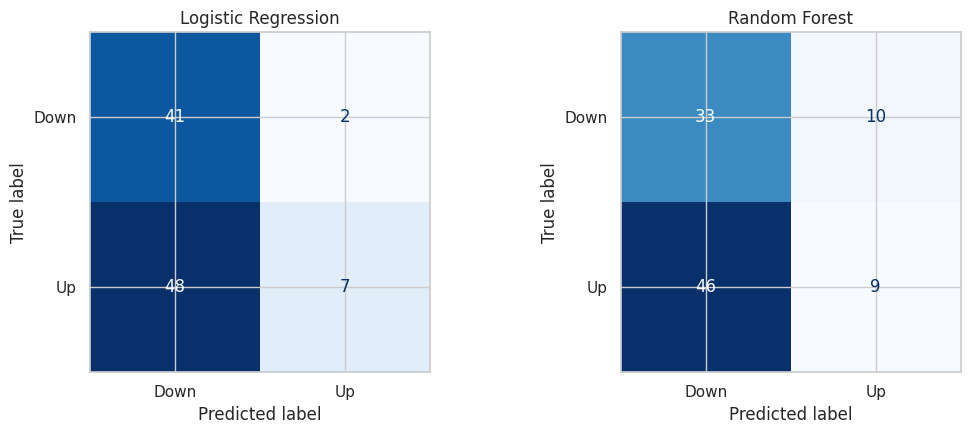

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (name, r) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, r["preds"])
    ConfusionMatrixDisplay(cm, display_labels=["Down", "Up"]).plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name)
plt.tight_layout()
plt.show()


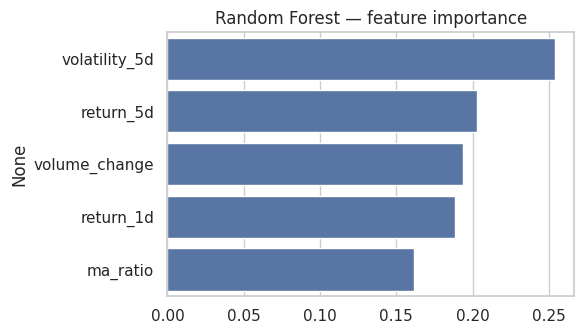

volatility_5d    0.253738
return_5d        0.203046
volume_change    0.193431
return_1d        0.188311
ma_ratio         0.161475
dtype: float64

In [14]:
rf = results["Random Forest"]["model"]
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
plt.figure(figsize=(6, 3.5))
sns.barplot(x=importances.values, y=importances.index)
plt.title("Random Forest — feature importance")
plt.tight_layout()
plt.show()
importances


## 5. Findings & conclusions

- **Price trend & risk:** AAPL trended upward over the sample period with an annualized volatility of roughly
  20–25%, and returns showed the volatility clustering typical of real markets rather than a smooth random walk.
- **Predictive modeling result:** both models land close to the naive baseline (predicting the majority class
  every day). This is an expected and honest finding, not a failure of the pipeline — short-horizon stock
  direction is close to a random walk, and this well-documented difficulty (the "efficient market" effect) is
  itself one of the most important lessons from applying data science to finance.
- **Most informative features:** short-term momentum (`return_1d`, `return_5d`) and the 5-day/20-day
  moving-average ratio carried the most weight, consistent with common technical-analysis intuition, even
  though their overall predictive power is modest.
- **Practical takeaway:** for real trading use, this kind of simple daily-direction classifier would need
  transaction-cost-aware backtesting, more data, and probably additional signals (market-wide indices,
  news/sentiment) before being trusted — exactly the kind of caveat a real finance data science role has to
  communicate to stakeholders.

**Expected outcome achieved:** applied a full data science workflow — cleaning, time-series EDA, feature
engineering, chronological train/test splitting, model comparison, and honest interpretation of results — to a
real-world finance dataset.
